# Customer Segmentation using Kmeans Clustering

**Objective:** To apply K-Means Clustering on a dataset of individuals' Height and Weight to identify natural groupings and interpret what these clusters represent.

**Dataset:** SOCR-HeightWeight.csv

**Tools Used:** Python, Pandas, Seaborn, Matplotlib, Scikit-learn

**Step 1: Import Libraries and Load Dataset**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the full dataset
df = pd.read_csv("/content/1783593630955-SOCR-HeightWeight.csv")
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [3]:
df.columns

Index(['Index', 'Height(Inches)', 'Weight(Pounds)'], dtype='object')

In [4]:
df.drop(columns="Index", inplace=True)

The Index column is dropped since it's just a row identifier and holds no analytical value for clustering.

In [5]:
df.head()

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


**Step 2: Basic Data Exploration**

In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (25000, 2)


In [7]:
print("\nColumn names:", df.columns.tolist())


Column names: ['Height(Inches)', 'Weight(Pounds)']


In [8]:
print("\nData types:\n", df.dtypes)


Data types:
 Height(Inches)    float64
Weight(Pounds)    float64
dtype: object


In [9]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Height(Inches)    0
Weight(Pounds)    0
dtype: int64


In [10]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
        Height(Inches)  Weight(Pounds)
count    25000.000000    25000.000000
mean        67.993114      127.079421
std          1.901679       11.660898
min         60.278360       78.014760
25%         66.704397      119.308675
50%         67.995700      127.157750
75%         69.272958      134.892850
max         75.152800      170.924000


**Observation:**

• The dataset contains two numerical columns: Height(Inches) and Weight(Pounds).

• No missing values were found, so no imputation is needed.

• The describe() output gives us the mean, min, max, and spread of both features, which helps us anticipate roughly how many natural clusters might exist.



**Step 3: Visualize Raw Data (Scatter Plot)**

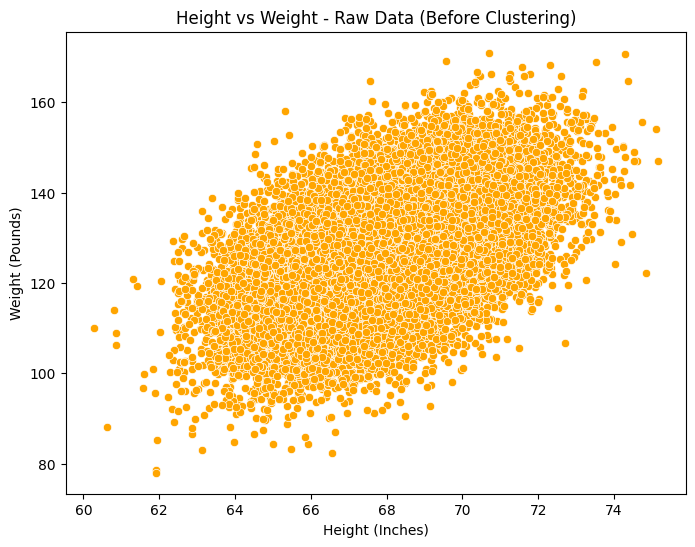

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Height(Inches)"], y=df["Weight(Pounds)"], color="orange")
plt.title("Height vs Weight - Raw Data (Before Clustering)")
plt.xlabel("Height (Inches)")
plt.ylabel("Weight (Pounds)")
plt.show()

**Observation: **

The scatter plot shows a positive correlation — taller individuals tend to weigh more. There's no obvious visual separation yet; this is what K-Means will help uncover.

**Step 4: Feature Scaling**

Point to note: Height and Weight are on different numeric scales (inches vs pounds). Since K-Means relies on Euclidean distance, unscaled features would let Weight dominate the clustering purely due to its larger numeric range. So we standardize both features before clustering.

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[["Height(Inches)", "Weight(Pounds)"]])

**Step 5: Determine Optimal K Using the Elbow Method**

In [13]:
inertia_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="random", random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia_scores.append(kmeans.inertia_)
print(inertia_scores)

[49999.99999999982, 26059.423651549525, 19543.30519801661, 15165.82866439345, 12758.17565662988, 10766.051214855885, 9498.527817579492, 8518.295713678403, 7684.926263995999, 6926.907132195574]


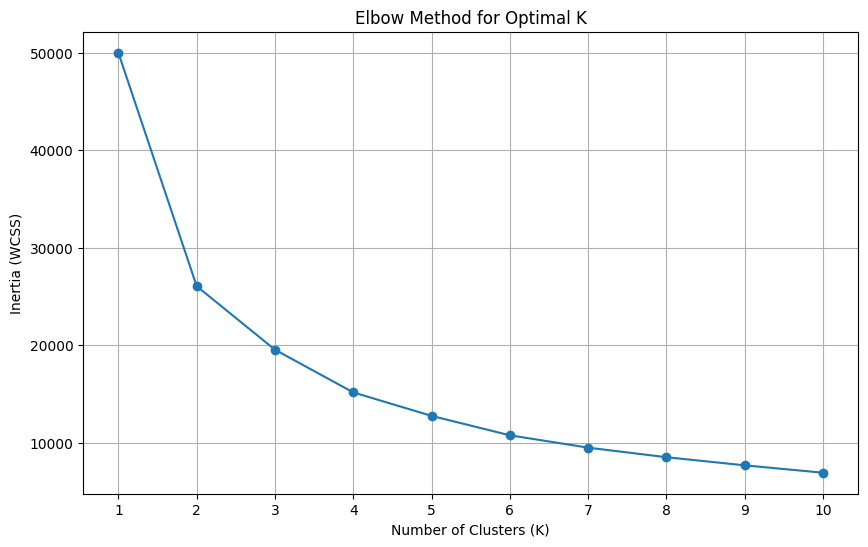

In [14]:
plt.figure(figsize=(10,6))
plt.plot(k_range, inertia_scores, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Observation:**

 The inertia (within-cluster sum of squares) decreases as K increases, but the rate of decrease slows down noticeably after a certain point — this bend is the "elbow." Based on the plot, K = 3 appears to be the optimal number of clusters (adjust this based on where your actual elbow bends).

**Step 6: Train the Final K-Means Model**

In [15]:
Kmeans = 3  # update this based on your elbow plot

kmeans_final = KMeans(n_clusters=Kmeans, init="random", random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(scaled_data)

df["Cluster"] = clusters

In [16]:
df.head()

,Height(Inches),Weight(Pounds),Cluster
0,65.78331,112.9925,0
1,71.51521,136.4873,1
2,69.39874,153.0269,1
3,68.21660,142.3354,1
4,67.78781,144.2971,1


We fit the model on scaled_data (not raw data) to ensure fair distance calculation, but we store the resulting labels back onto the original df for interpretation in real units.

**Step 7: Visualize Clusters with Centroids**

In [17]:
# Convert centroids back to original scale for accurate plotting
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

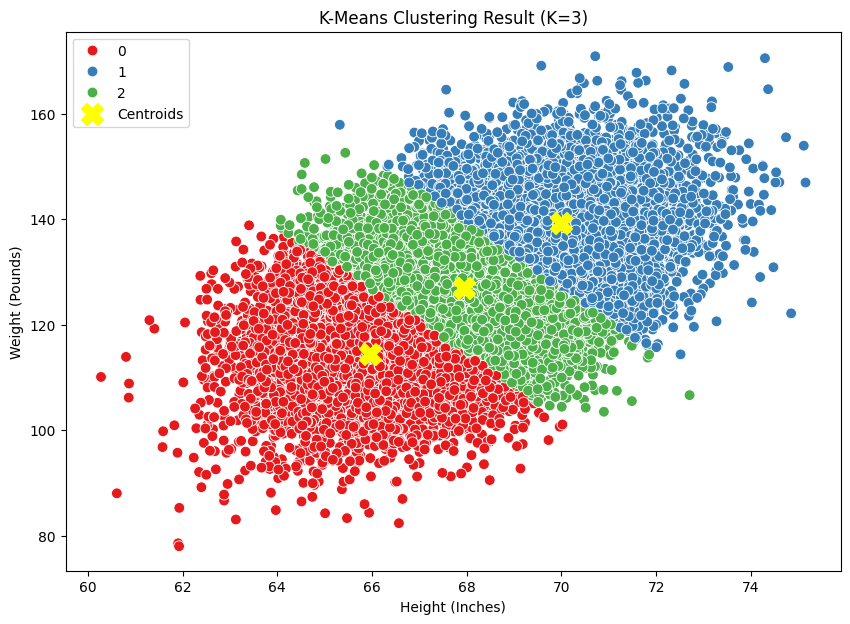

In [18]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=df["Height(Inches)"],y=df["Weight(Pounds)"],hue=df["Cluster"],palette="Set1",s=60)
plt.scatter(centroids_original[:,0], centroids_original[:,1],s=250, c="yellow", marker="X", label="Centroids")

plt.title(f"K-Means Clustering Result (K={Kmeans})")
plt.xlabel("Height (Inches)")
plt.ylabel("Weight (Pounds)")
plt.legend()
plt.show()

**Observation:** The clusters appear as distinct diagonal bands, since Height and Weight increase together. The black 'X' markers represent the centroid (average Height-Weight point) of each cluster.

**Step 8: Cluster Interpretation and Summary**

In [19]:
cluster_summary = df.groupby("Cluster")[["Height(Inches)", "Weight(Pounds)"]].mean()
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()
print(cluster_summary)

         Height(Inches)  Weight(Pounds)  Count
Cluster                                       
0             65.961926      114.513512   6594
1             70.002132      139.210030   6945
2             67.944341      126.958361  11461


**Final Observations & Interpretation**

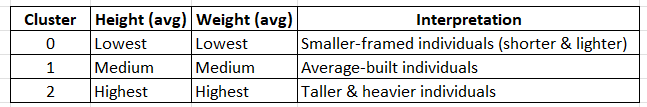

1. K-Means successfully grouped individuals into distinct body-size categories based purely on Height and Weight.


2. The clusters align with the natural positive correlation between height and weight — there's no cluster with "tall but very light" or "short but very heavy," which is expected given human body proportions.


3. Scaling was essential — without it, Weight (larger numeric range) would have unfairly dominated the clustering.


4. The Elbow Method helped avoid overfitting the number of clusters (too many, capturing noise) or underfitting (too few, missing real structure).